In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler

In [74]:
file_path = file_path = r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\Autism Dataset for Toddlers.csv"
data = pd.read_csv(file_path)
data.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


Pre processing

In [75]:
# Drop the 'Case_No' column as it's not relevant for modeling
data = data.drop(columns=['Case_No'])



In [76]:
missing_data = data.isnull().sum()
total_missing = missing_data[missing_data > 0].sum()
if total_missing > 0:
    print(f"Total number of missing values in the dataset: {total_missing}")
    print("Missing data by column:")
    print(missing_data[missing_data > 0].to_string())
else:
    print("No missing data in the dataset.")

No missing data in the dataset.


In [77]:
duplicates = data.duplicated().sum()
if duplicates > 0:
    print(f"Total number of duplicate rows in the dataset: {duplicates}")
else:
    print("No duplicate rows in the dataset.")

Total number of duplicate rows in the dataset: 79


In [78]:
# Drop duplicate rows
data = data.drop_duplicates()

duplicates = data.duplicated().sum()
if duplicates > 0:
    print(f"Total number of duplicate rows in the dataset: {duplicates}")
else:
    print("No duplicate rows in the dataset.")

No duplicate rows in the dataset.


In [79]:
# Check the data types of each column
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                         int64
A2                         int64
A3                         int64
A4                         int64
A5                         int64
A6                         int64
A7                         int64
A8                         int64
A9                         int64
A10                        int64
Age_Mons                   int64
Qchat-10-Score             int64
Sex                       object
Ethnicity                 object
Jaundice                  object
Family_mem_with_ASD       object
Who completed the test    object
Class/ASD Traits          object
dtype: object


In [80]:
# Check basic statistics of numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
print("Summary statistics of numerical columns:")
print(data[numerical_columns].describe())

Summary statistics of numerical columns:
               A1          A2          A3          A4          A5          A6  \
count  975.000000  975.000000  975.000000  975.000000  975.000000  975.000000   
mean     0.575385    0.457436    0.397949    0.517949    0.530256    0.583590   
std      0.494538    0.498441    0.489726    0.499934    0.499340    0.493216   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      1.000000    0.000000    0.000000    1.000000    1.000000    1.000000   
75%      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

               A7          A8          A9         A10    Age_Mons  \
count  975.000000  975.000000  975.000000  975.000000  975.000000   
mean     0.667692    0.464615    0.497436    0.585641   27.899487   
std      0.471282    0

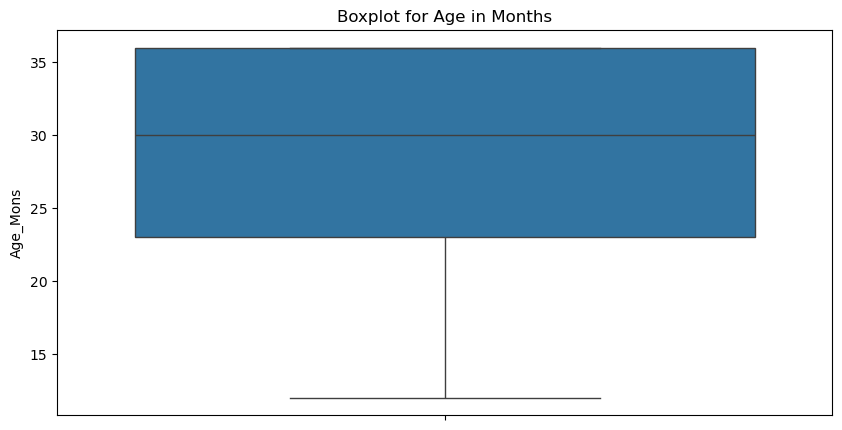

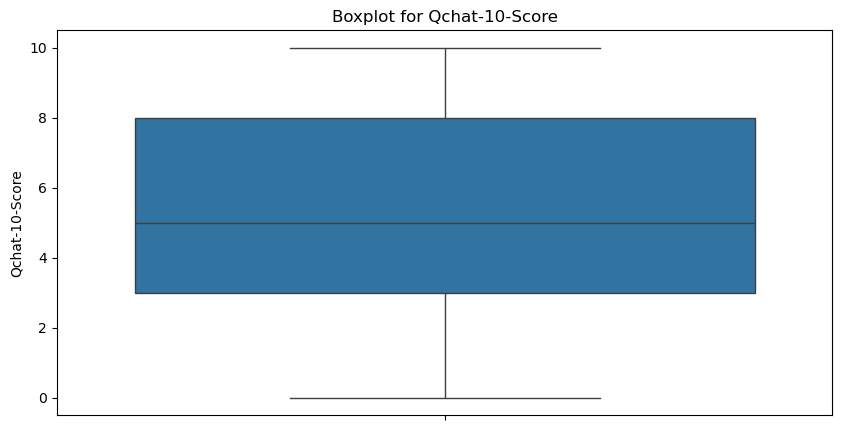

In [81]:
# Boxplot for Age_Mons
plt.figure(figsize=(10, 5))
sns.boxplot(data['Age_Mons'])
plt.title('Boxplot for Age in Months')
plt.show()

# Boxplot for Qchat-10-Score
plt.figure(figsize=(10, 5))
sns.boxplot(data['Qchat-10-Score'])
plt.title('Boxplot for Qchat-10-Score')
plt.show()

# IQR method for Age_Mons and Qchat-10-Score
Q1_age = data['Age_Mons'].quantile(0.25)
Q3_age = data['Age_Mons'].quantile(0.75)
IQR_age = Q3_age - Q1_age

Q1_qchat = data['Qchat-10-Score'].quantile(0.25)
Q3_qchat = data['Qchat-10-Score'].quantile(0.75)
IQR_qchat = Q3_qchat - Q1_qchat

In [82]:
age_outliers = data[(data['Age_Mons'] < (Q1_age - 1.5 * IQR_age)) | (data['Age_Mons'] > (Q3_age + 1.5 * IQR_age))]

# Outliers for Qchat-10-Score
qchat_outliers = data[(data['Qchat-10-Score'] < (Q1_qchat - 1.5 * IQR_qchat)) | (data['Qchat-10-Score'] > (Q3_qchat + 1.5 * IQR_qchat))]

# Display the number of outliers
print(f"Number of outliers in Age_Mons: {age_outliers.shape[0]}")
print(f"Number of outliers in Qchat-10-Score: {qchat_outliers.shape[0]}")

Number of outliers in Age_Mons: 0
Number of outliers in Qchat-10-Score: 0


In [83]:
binary_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
for col in binary_columns:
    print(f"Unique values in {col}: {data[col].unique()}")
    print(f"Value counts in {col}: \n{data[col].value_counts()}\n")

Unique values in A1: [0 1]
Value counts in A1: 
A1
1    561
0    414
Name: count, dtype: int64

Unique values in A2: [0 1]
Value counts in A2: 
A2
0    529
1    446
Name: count, dtype: int64

Unique values in A3: [0 1]
Value counts in A3: 
A3
0    587
1    388
Name: count, dtype: int64

Unique values in A4: [0 1]
Value counts in A4: 
A4
1    505
0    470
Name: count, dtype: int64

Unique values in A5: [0 1]
Value counts in A5: 
A5
1    517
0    458
Name: count, dtype: int64

Unique values in A6: [0 1]
Value counts in A6: 
A6
1    569
0    406
Name: count, dtype: int64

Unique values in A7: [1 0]
Value counts in A7: 
A7
1    651
0    324
Name: count, dtype: int64

Unique values in A8: [1 0]
Value counts in A8: 
A8
0    522
1    453
Name: count, dtype: int64

Unique values in A9: [0 1]
Value counts in A9: 
A9
0    490
1    485
Name: count, dtype: int64

Unique values in A10: [1 0]
Value counts in A10: 
A10
1    571
0    404
Name: count, dtype: int64



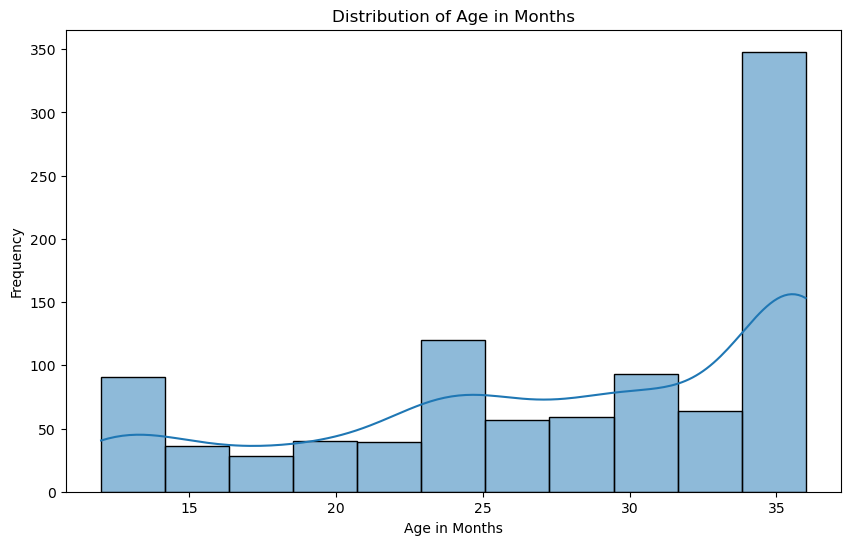

Skewness of Age_Mons: -0.6324301160818052


In [84]:
# Plot the distribution of 'Age_Mons'
plt.figure(figsize=(10, 6))
sns.histplot(data['Age_Mons'], kde=True)
plt.title('Distribution of Age in Months')
plt.xlabel('Age in Months')
plt.ylabel('Frequency')
plt.show()

# Check the skewness of the 'Age_Mons' column
age_skewness = skew(data['Age_Mons'])
print(f"Skewness of Age_Mons: {age_skewness}")

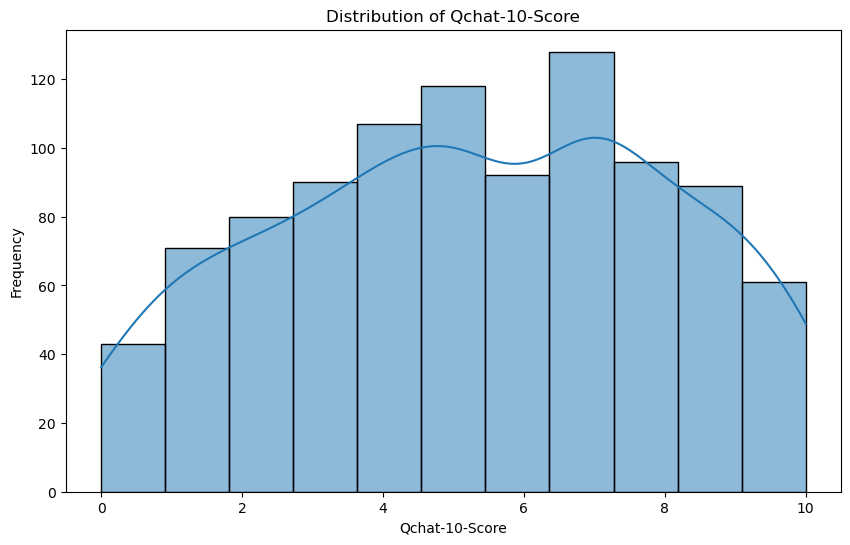

Skewness of Qchat-10-Score: -0.10784204158540804


In [85]:
# Plot the distribution of 'Qchat-10-Score'
plt.figure(figsize=(10, 6))
sns.histplot(data['Qchat-10-Score'], kde=True)
plt.title('Distribution of Qchat-10-Score')
plt.xlabel('Qchat-10-Score')
plt.ylabel('Frequency')
plt.show()

# Check the skewness of the 'Qchat-10-Score' column
qchat_skewness = skew(data['Qchat-10-Score'])
print(f"Skewness of Qchat-10-Score: {qchat_skewness}")

In [86]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
print("\nCategorical columns identified:")
print(categorical_columns)


Categorical columns identified:
Index(['Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD',
       'Who completed the test', 'Class/ASD Traits '],
      dtype='object')


In [87]:
# Inspect unique values in each categorical column
for col in categorical_columns:
    print(f"Unique values in {col}:")
    print(data[col].unique())
    print("\n")

Unique values in Sex:
['f' 'm']


Unique values in Ethnicity:
['middle eastern' 'White European' 'Hispanic' 'black' 'asian'
 'south asian' 'Native Indian' 'Others' 'Latino' 'mixed' 'Pacifica']


Unique values in Jaundice:
['yes' 'no']


Unique values in Family_mem_with_ASD:
['no' 'yes']


Unique values in Who completed the test:
['family member' 'Health Care Professional' 'Health care professional'
 'Self' 'Others']


Unique values in Class/ASD Traits :
['No' 'Yes']




In [88]:
# Clean 'Who completed the test' column
data['Who completed the test'] = data['Who completed the test'].replace(
    {'Health care professional': 'Health Care Professional'}
)

data['Who completed the test'] = data['Who completed the test'].replace(
    {'Self': 'Others'}
)


# Inspect again the unique values in the 'Who completed the test' column
print(data['Who completed the test'].unique())

['family member' 'Health Care Professional' 'Others']


In [89]:
# One-hot encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Identify the new one-hot encoded columns
encoded_categorical_columns = [col for col in data_encoded.columns if col not in data.columns]

# Show the first few rows of the newly encoded categorical columns
encoded_categorical_data = data_encoded[encoded_categorical_columns]
print(encoded_categorical_data.head())

   Sex_m  Ethnicity_Latino  Ethnicity_Native Indian  Ethnicity_Others  \
0  False             False                    False             False   
1   True             False                    False             False   
2   True             False                    False             False   
3   True             False                    False             False   
4  False             False                    False             False   

   Ethnicity_Pacifica  Ethnicity_White European  Ethnicity_asian  \
0               False                     False            False   
1               False                      True            False   
2               False                     False            False   
3               False                     False            False   
4               False                      True            False   

   Ethnicity_black  Ethnicity_middle eastern  Ethnicity_mixed  \
0            False                      True            False   
1            False    

In [90]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the 'Age_Mons' feature
data_encoded['Age_Mons'] = scaler.fit_transform(data_encoded[['Age_Mons']])

# Show the standardized data
print(data_encoded[['Age_Mons']].head())

   Age_Mons
0  0.012802
1  1.031739
2  1.031739
3 -0.496666
4 -1.006135


In [91]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the 'Qchat-10-Score' feature
data_encoded['Qchat-10-Score'] = scaler.fit_transform(data_encoded[['Qchat-10-Score']])

# Show the standardized data
print(data_encoded[['Qchat-10-Score']].head())


   Qchat-10-Score
0       -0.808509
1       -0.453580
2       -0.453580
3        1.675991
4        1.321062


In [92]:
# Check the data types of each column
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                         int64
A2                         int64
A3                         int64
A4                         int64
A5                         int64
A6                         int64
A7                         int64
A8                         int64
A9                         int64
A10                        int64
Age_Mons                   int64
Qchat-10-Score             int64
Sex                       object
Ethnicity                 object
Jaundice                  object
Family_mem_with_ASD       object
Who completed the test    object
Class/ASD Traits          object
dtype: object


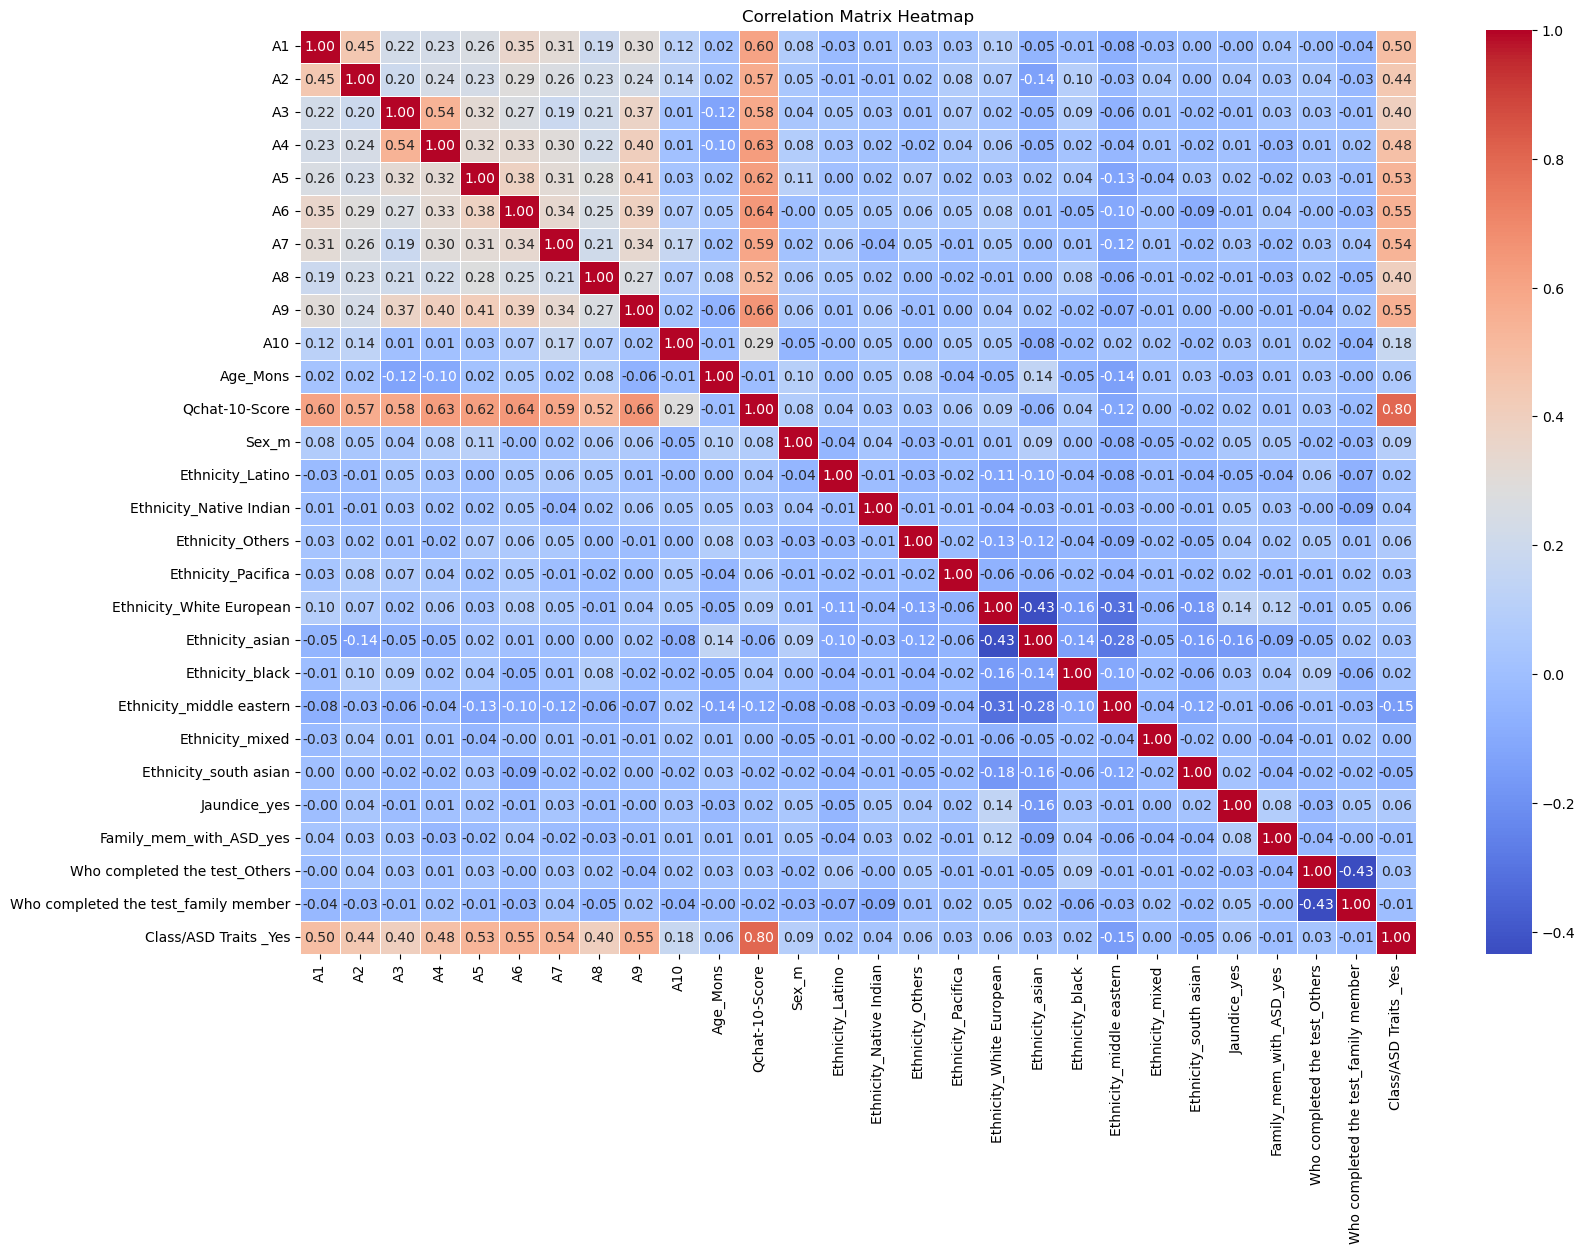

In [93]:
# Compute the correlation matrix
correlation_matrix = data_encoded.corr()
# Plot the heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [94]:
# Drop the `Ethnicity_*` columns (those that are already one-hot encoded)
ethnicity_columns = [col for col in data_encoded.columns if 'Ethnicity_' in col]

# Drop those columns from the data
data_encoded = data_encoded.drop(columns=ethnicity_columns)

# Show the first few rows after dropping the `Ethnicity_*` columns
print(data_encoded.head())

   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  Sex_m  \
0   0   0   0   0   0   0   1   1   0    1  0.012802       -0.808509  False   
1   1   1   0   0   0   1   1   0   0    0  1.031739       -0.453580   True   
2   1   0   0   0   0   0   1   1   0    1  1.031739       -0.453580   True   
3   1   1   1   1   1   1   1   1   1    1 -0.496666        1.675991   True   
4   1   1   0   1   1   1   1   1   1    1 -1.006135        1.321062  False   

   Jaundice_yes  Family_mem_with_ASD_yes  Who completed the test_Others  \
0          True                    False                          False   
1          True                    False                          False   
2          True                    False                          False   
3         False                    False                          False   
4         False                     True                          False   

   Who completed the test_family member  Class/ASD Traits _Yes  
0        

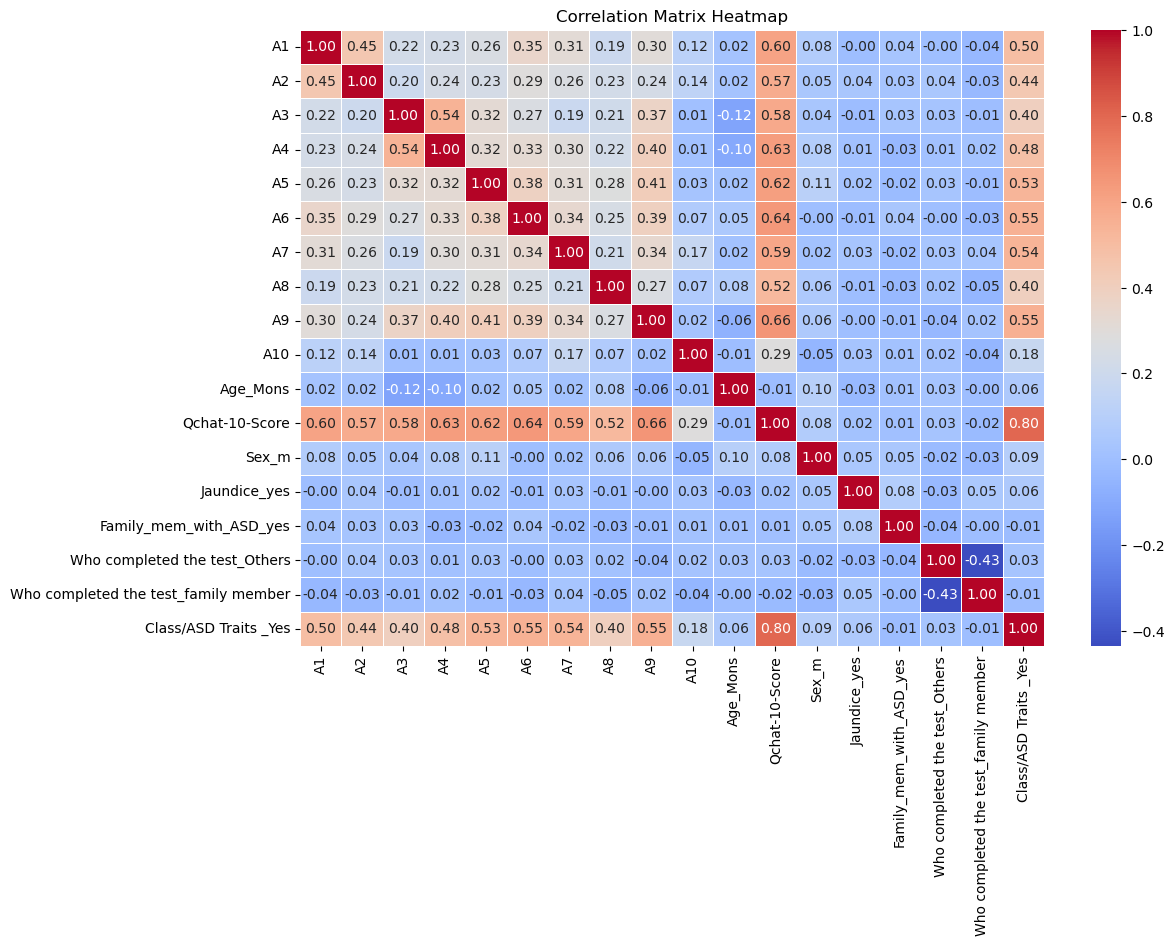

In [95]:
# Compute the correlation matrix
correlation_matrix = data_encoded.corr()
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [96]:
# Save the pre-processed data to a CSV file
output_file_path = r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data.csv"
data_encoded.to_csv(output_file_path, index=False)

In [25]:
# Check the data types of each column
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                         int64
A2                         int64
A3                         int64
A4                         int64
A5                         int64
A6                         int64
A7                         int64
A8                         int64
A9                         int64
A10                        int64
Age_Mons                   int64
Qchat-10-Score             int64
Sex                       object
Ethnicity                 object
Jaundice                  object
Family_mem_with_ASD       object
Who completed the test    object
Class/ASD Traits          object
dtype: object
